In [11]:
import numpy as np
import seaborn as sns
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt

# Dataset (breast cancer)

- `0`: malignant
- `1`: benign

`x`: 30 variables
`y`: target variable

569 samples


In [2]:
dataset = load_breast_cancer(as_frame=True)
x = dataset.data.to_numpy(dtype=float)
y = dataset.target.to_numpy(dtype=float)

In [3]:
# standardize the features
x_mean = x.mean(axis=0)
x_std = x.std(axis=0)
x_std = np.where(x_std == 0, 1, x_std)

x = (x - x_mean) / x_std

In [4]:
def sigmoid(x, m, c):
    z = (x @ m) + c
    return 1 / (1 + np.exp(-z))

In [5]:
def calc_updated_m_c(x, y, m, c, alpha):
    n = x.shape[0]
    y_probs = sigmoid(x, m, c)

    loss = -np.mean(y * np.log(y_probs) + (1 - y) * np.log(1 - y_probs))

    m_gradient = (x.T @ (y_probs - y)) / n
    c_gradient = np.mean(y_probs - y)

    updated_m = m - alpha * m_gradient
    updated_c = c - alpha * c_gradient
    return updated_m, updated_c, loss

In [6]:
def training_loop(x, y, epochs=1000, alpha=0.0001):
    m = np.zeros(x.shape[1])
    c = 0.0

    for e in range(epochs):
        m, c, loss = calc_updated_m_c(x, y, m, c, alpha)

        if e % 100 == 0:
            print(f"[Epoch {e}] Error: {loss}")

    return m, c

In [21]:
def plot_results(x, y, m=None, c=None):
    threshold = 0.75
    z = (x @ m) + c
    y_probs = sigmoid(x, m, c)
    y_pred = np.where(y_probs >= threshold, 1, 0)

    _, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax in axes:
        sns.lineplot(x=z, y=y_probs, color="red", label="Sigmoid", ax=ax)
        ax.set_xlabel("Linear score (z)")

    sns.scatterplot(x=z, y=y_pred, marker="+", label="Predicted class", ax=axes[0])
    axes[0].set_ylabel("Predicted class")

    sns.scatterplot(
        x=z,
        y=y,
        marker="o",
        label="Actual class",
    )
    ax.set_ylabel("Actual class")

    plt.tight_layout()
    plt.show()

In [23]:
m, c = training_loop(x, y, 3000, 0.001)

[Epoch 0] Error: 0.6931471805599453
[Epoch 100] Error: 0.5431339347791843
[Epoch 200] Error: 0.4564649458619442
[Epoch 300] Error: 0.40029131355297826
[Epoch 400] Error: 0.36068285231959435
[Epoch 500] Error: 0.33105313328965236
[Epoch 600] Error: 0.3079124816451579
[Epoch 700] Error: 0.289241677801966
[Epoch 800] Error: 0.2737905145500061
[Epoch 900] Error: 0.26074257378276655
[Epoch 1000] Error: 0.2495413165479777
[Epoch 1100] Error: 0.23979370063033728
[Epoch 1200] Error: 0.23121379705142056
[Epoch 1300] Error: 0.22358828645296808
[Epoch 1400] Error: 0.2167545250524595
[Epoch 1500] Error: 0.21058613854005606
[Epoch 1600] Error: 0.20498328887837064
[Epoch 1700] Error: 0.19986593352074825
[Epoch 1800] Error: 0.19516905398961437
[Epoch 1900] Error: 0.1908392122215817
[Epoch 2000] Error: 0.18683202157552917
[Epoch 2100] Error: 0.18311026018651405
[Epoch 2200] Error: 0.17964244332238313
[Epoch 2300] Error: 0.17640172892860564
[Epoch 2400] Error: 0.17336506852097863
[Epoch 2500] Error: 0.

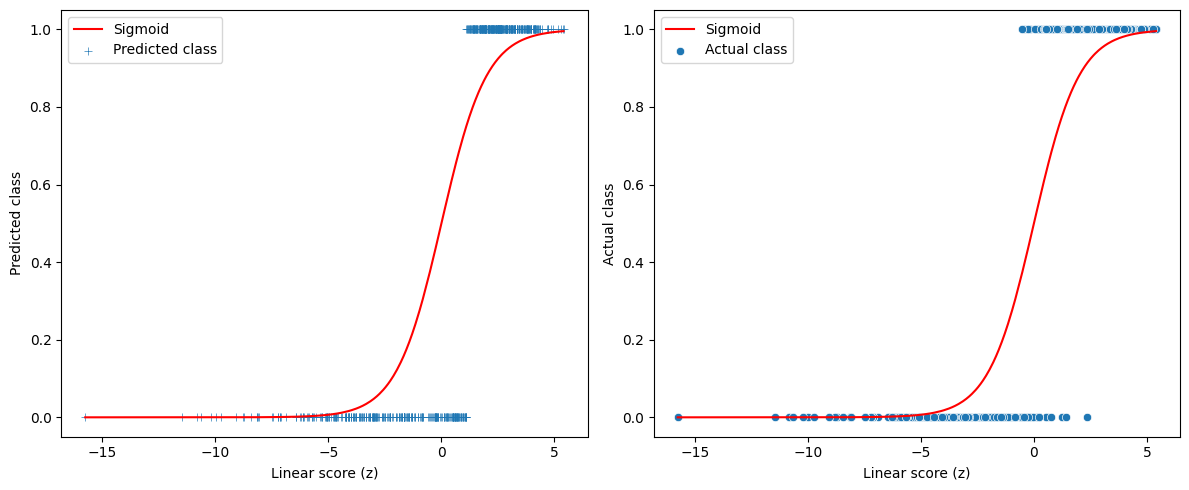

In [24]:
plot_results(x, y, m, c)